# Part 3: Churn Prediction Model & Model Card

Author: Apurva Jain

Objective:
Build a churn prediction model capable of identifying customers likely to churn within the next 60 days.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

data = pd.read_csv("rfm_modeling_snapshot.csv")

data.shape

(2400, 29)

In [3]:
data.head()
data.info()
data["churn_next_60d"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category

,count
churn_next_60d,
0,1273
1,1127



## Leakage Prevention

The project uses the provided modeling snapshot dataset.
All features are generated at the customer snapshot date.

The target variable is:

churn_next_60d

This target column is removed from model inputs.

No post-snapshot transactions are used as features.

In [4]:
train_df = data[data["split"]=="train"]
val_df   = data[data["split"]=="validation"]
test_df  = data[data["split"]=="test"]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(1728, 29)
(336, 29)
(336, 29)


In [5]:
target = "churn_next_60d"

drop_cols = [
    "customer_id",
    "snapshot_date",
    "split",
    target
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]

In [6]:
from sklearn.preprocessing import LabelEncoder

for col in X_train.select_dtypes(include="object").columns:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    X_val[col] = le.transform(X_val[col].astype(str))

    X_test[col] = le.transform(X_test[col].astype(str))##

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [26]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(
    max_iter=5000,
    random_state=42
)

baseline.fit(X_train_scaled, y_train)

val_pred = baseline.predict(X_val_scaled)

print(classification_report(y_val, val_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       189
           1       0.82      0.75      0.78       147

    accuracy                           0.82       336
   macro avg       0.82      0.81      0.81       336
weighted avg       0.82      0.82      0.82       336



In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_val_pred = rf.predict(X_val)

print(
    classification_report(
        y_val,
        rf_val_pred
    )
)

              precision    recall  f1-score   support

           0       0.80      0.85      0.83       189
           1       0.79      0.73      0.76       147

    accuracy                           0.80       336
   macro avg       0.80      0.79      0.79       336
weighted avg       0.80      0.80      0.80       336



In [9]:
rf_probs = rf.predict_proba(X_val)[:,1]

rf_probs[:5]

array([0.23      , 0.22333333, 0.48666667, 0.09666667, 0.09666667])

## Threshold Selection

The business prefers identifying churners even at the cost of some false positives.

A threshold of 0.40 is selected to improve churn recall and increase the number of customers available for retention campaigns.

In [10]:
threshold = 0.40

custom_pred = (
    rf_probs >= threshold
).astype(int)

print(
    classification_report(
        y_val,
        custom_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.78      0.80       189
           1       0.74      0.79      0.76       147

    accuracy                           0.79       336
   macro avg       0.78      0.79      0.78       336
weighted avg       0.79      0.79      0.79       336



In [11]:
rf_test_probs = rf.predict_proba(X_test)[:,1]

rf_test_pred = (
    rf_test_probs >= threshold
).astype(int)

print(
    classification_report(
        y_test,
        rf_test_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.73      0.77       168
           1       0.76      0.85      0.80       168

    accuracy                           0.79       336
   macro avg       0.79      0.79      0.79       336
weighted avg       0.79      0.79      0.79       336



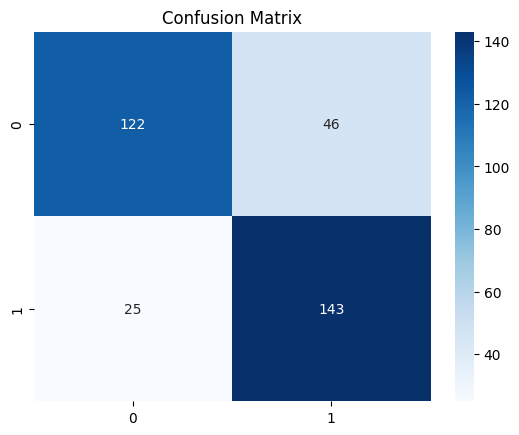

In [12]:
cm = confusion_matrix(
    y_test,
    rf_test_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [13]:
importance = pd.DataFrame({
    "feature":X_train.columns,
    "importance":rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(10)

,feature,importance
6,recency_days,0.231612
24,last_visit_days_ago,0.139070
8,monetary_180d,0.089961
16,days_since_signup,0.058711
10,avg_discount_pct_180d,0.055010
18,product_views_30d,0.052895
17,sessions_30d,0.040250
7,frequency_180d,0.038487
11,avg_rating_180d,0.028597
12,category_diversity_180d,0.026838


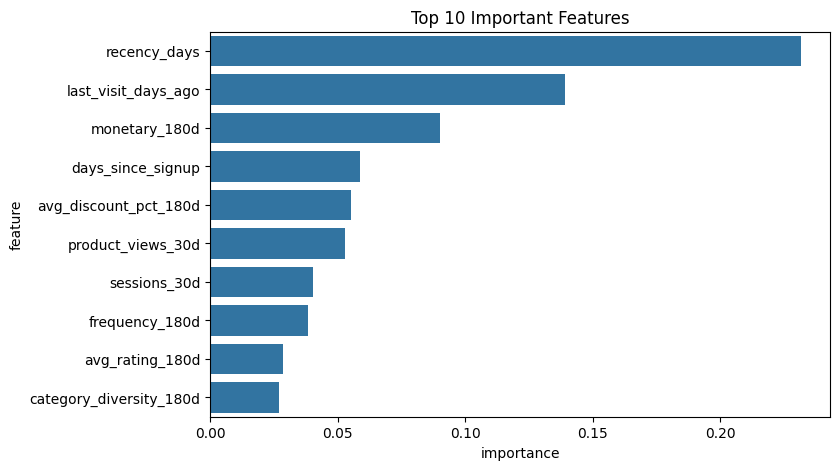

In [14]:
top10 = importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x="importance",
    y="feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [15]:
import joblib

joblib.dump(
    rf,
    "model.pkl"
)

print("Model Saved")

Model Saved


In [16]:
import json

metrics = {

    "accuracy":
    float(
        accuracy_score(
            y_test,
            rf_test_pred
        )
    ),

    "precision":
    float(
        precision_score(
            y_test,
            rf_test_pred
        )
    ),

    "recall":
    float(
        recall_score(
            y_test,
            rf_test_pred
        )
    ),

    "f1":
    float(
        f1_score(
            y_test,
            rf_test_pred
        )
    ),

    "roc_auc":
    float(
        roc_auc_score(
            y_test,
            rf_test_probs
        )
    ),

    "threshold":
    threshold,

    "confusion_matrix":
    cm.tolist()
}

with open(
    "metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

print(metrics)

{'accuracy': 0.7886904761904762, 'precision': 0.7566137566137566, 'recall': 0.8511904761904762, 'f1': 0.8011204481792717, 'roc_auc': 0.8745748299319728, 'threshold': 0.4, 'confusion_matrix': [[122, 46], [25, 143]]}


In [ ]:
accuracy ≈ 0.789
precision ≈ 0.757
recall ≈ 0.851
f1 ≈ 0.801

#Error Analysis Sectoin

In [17]:
test_results = test_df.copy()

test_results["actual"] = y_test.values

test_results["predicted"] = rf_test_pred

test_results["probability"] = rf_test_probs

test_results.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split,actual,predicted,probability
15,CUST00016,2025-09-30,Tier 2,18-24,Instagram,NaN,Skin Care,Yes,215,0,...,0,0,4,1,32,1,test,1,1,0.970000
17,CUST00018,2025-09-30,Tier 1,35-44,Marketplace,Silver,Skin Care,Yes,111,1,...,0,0,4,2,37,1,test,1,1,0.830000
23,CUST00024,2025-09-30,Tier 1,25-34,Marketplace,NaN,Skin Care,Yes,4,1,...,2,2,3,0,0,0,test,0,0,0.040000
24,CUST00025,2025-09-30,Tier 2,18-24,Referral,NaN,Baby Care,Yes,165,1,...,3,1,6,1,29,1,test,1,1,0.673333
29,CUST00030,2025-09-30,Tier 1,25-34,Google Search,Gold,Wellness,No,5,5,...,3,1,0,0,3,0,test,0,0,0.060000


In [18]:
false_positive = test_results[
    (test_results["actual"]==0) &
    (test_results["predicted"]==1)
]

false_positive[
    [
        "customer_id",
        "probability",
        "recency_days",
        "frequency_180d",
        "monetary_180d"
    ]
].head(5)

,customer_id,probability,recency_days,frequency_180d,monetary_180d
43,CUST00044,0.613333,72,1,899.51
108,CUST00109,0.540000,92,2,1622.28
191,CUST00192,0.410000,55,3,2263.95
249,CUST00250,0.400000,35,1,837.19
334,CUST00335,0.653333,148,2,1328.14


In [19]:
false_negative = test_results[
    (test_results["actual"]==1) &
    (test_results["predicted"]==0)
]

false_negative[
    [
        "customer_id",
        "probability",
        "recency_days",
        "frequency_180d",
        "monetary_180d"
    ]
].head(5)

,customer_id,probability,recency_days,frequency_180d,monetary_180d
183,CUST00184,0.026667,14,3,2456.91
246,CUST00247,0.386667,57,2,937.32
378,CUST00379,0.390000,75,1,538.25
413,CUST00414,0.310000,3,1,311.44
437,CUST00438,0.313333,64,3,2466.39


In [20]:
examples = pd.concat([
    false_positive.head(5),
    false_negative.head(5)
])

examples.to_csv(
    "error_examples.csv",
    index=False
)

examples.head(10)

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split,actual,predicted,probability
43,CUST00044,2025-09-30,Tier 2,35-44,Google Search,NaN,Baby Care,Yes,72,1,...,1,1,4,2,10,0,test,0,1,0.613333
108,CUST00109,2025-09-30,Tier 1,25-34,Instagram,Silver,Skin Care,Yes,92,2,...,0,0,3,1,16,0,test,0,1,0.540000
191,CUST00192,2025-09-30,Tier 1,25-34,Instagram,NaN,Makeup,Yes,55,3,...,1,1,4,1,30,0,test,0,1,0.410000
249,CUST00250,2025-09-30,Tier 1,25-34,Referral,Silver,Baby Care,No,35,1,...,1,0,0,0,2,0,test,0,1,0.400000
334,CUST00335,2025-09-30,Tier 2,45+,Instagram,NaN,Skin Care,Yes,148,2,...,1,0,3,1,22,0,test,0,1,0.653333
183,CUST00184,2025-09-30,Tier 1,18-24,Instagram,Platinum,Wellness,No,14,3,...,1,0,0,0,6,1,test,1,0,0.026667
246,CUST00247,2025-09-30,Tier 2,25-34,Marketplace,NaN,Hair Care,Yes,57,2,...,0,1,5,2,14,1,test,1,0,0.386667
378,CUST00379,2025-09-30,Tier 1,45+,Marketplace,NaN,Hair Care,No,75,1,...,0,1,0,0,4,1,test,1,0,0.390000
413,CUST00414,2025-09-30,Tier 2,25-34,Marketplace,NaN,Baby Care,Yes,3,1,...,1,2,6,1,0,1,test,1,0,0.310000
437,CUST00438,2025-09-30,Tier 1,25-34,Marketplace,Platinum,Baby Care,Yes,64,3,...,1,1,7,2,22,1,test,1,0,0.313333


In [21]:
importance.head(10)

,feature,importance
6,recency_days,0.231612
24,last_visit_days_ago,0.139070
8,monetary_180d,0.089961
16,days_since_signup,0.058711
10,avg_discount_pct_180d,0.055010
18,product_views_30d,0.052895
17,sessions_30d,0.040250
7,frequency_180d,0.038487
11,avg_rating_180d,0.028597
12,category_diversity_180d,0.026838
